In [2]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)


In [3]:
drds <- "./05mm_data/"
n=0
for(s in Sys.glob(file.path(drds,"*_mm.RDS"))){
    n=n+1
    key <- gsub("_mm.RDS","",basename(s))
    sp <- readRDS(paste0(drds,key,"_mm.RDS"))
    m <- sp@meta.data
    rownames(m) <- paste0(key,rownames(m))
    if(n==1){
        m1 <- m
    }
    else{
        m1 <- rbind(m1,m)
    }
}

In [58]:
setwd("./13S1_update/")

In [38]:
mer <- m1[which(m1$sample=="save"),]
mer$`Week ID` <- str_replace(mer$`Week ID`,"W","AS_W")
mer$`Week ID` <- str_replace(mer$`Week ID`,"AS_W20_con_","N_W20_")
table(mer$Celltype)


     EC     FBs  Macro.  mSMCss    SMCs T cells 
  27672   72437  190325  132760  209005    1871 

In [39]:
library(reshape2)

In [40]:
cols1 <- c('T cells'="#ce1256",'SMCs'="#1f78b4",'mSMCss'="#A1CFFA",'Macro.'="#df65b0",'FBs'="#8b4a4b",'EC'="#238b45")

         
              W0    W10     W2    W20  W20_N     W6
  EC         937   7924   5121   8259   1350   4081
  FBs       3634  17582  13385  21532   5577  10727
  Macro.    1302  32205   4440 136293   1223  14862
  mSMCss    2723  15248   6468  97920   3728   6673
  SMCs     19016  44952  43743  30601  27835  42858
  T cells     21    445    311    757    152    185

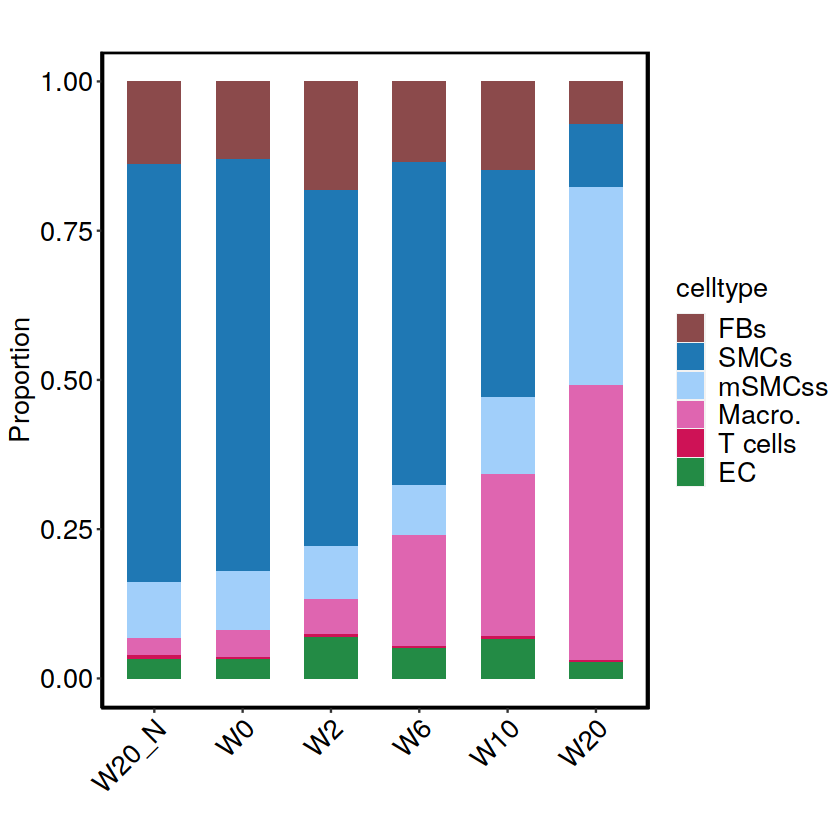

In [41]:
m <- as.matrix(table(as.character(mer$Celltype), mer$Week))
m
plot_df <- melt(m)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$y <- factor(plot_df$y, levels = c("W20_N",'W0','W2','W6',"W10","W20"))
plot_df$celltype <- factor(plot_df$celltype, levels = c('FBs','SMCs','mSMCss','Macro.','T cells','EC'))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',width = 0.6,position="fill")+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title    = element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'), # y轴线特征
    axis.line.x = element_line (color = 'black',linetype = 'solid'), # x轴线特征
    panel.background=element_rect(fill="white"),
    panel.border = element_rect(linetype = 'solid', size = 1.2,fill = NA) # 图四周框起来
  )+scale_fill_manual(values = cols1)
print(p1)

In [42]:
wid <- unique(mer$`Week ID`)

In [64]:
ord <-c('N_W20_1a','N_W20_2a','N_W20_2b','N_W20_3a','N_W20_3b','N_W20_4a','N_W20_5a',###W20_N
        'AS_W0_1a','AS_W0_2a','AS_W0_2b',###W0
        'AS_W2_1a','AS_W2_1b','AS_W2_2a','AS_W2_2b','AS_W2_4a','AS_W2_4b','AS_W2_5b','AS_W2_6a','AS_W2_6b','AS_W2_7b','AS_W2_8b',####W2
        'AS_W6_1a','AS_W6_4a','AS_W6_4b','AS_W6_6a','AS_W6_6b','AS_W6_7a','AS_W6_7b','AS_W6_8a','AS_W6_9a','AS_W6_9b','AS_W6_10a','AS_W6_10b',#####W6
        'AS_W10_1a','AS_W10_1b','AS_W10_2a','AS_W10_2b','AS_W10_3a','AS_W10_3b','AS_W10_5a','AS_W10_5b','AS_W10_6a','AS_W10_6b','AS_W10_7a','AS_W10_7b','AS_W10_8a','AS_W10_8b',####W10
        'AS_W20_3a','AS_W20_3b','AS_W20_6a','AS_W20_6b','AS_W20_7a','AS_W20_7b','AS_W20_8a','AS_W20_8b','AS_W20_9a','AS_W20_9b','AS_W20_10b','AS_W20_11a','AS_W20_11b','AS_W20_12a','AS_W20_12b','AS_W20_1a','AS_W20_1b','AS_W20_2a','AS_W20_4a','AS_W20_4b','AS_W20_5a','AS_W20_5b'
        ###W20
)

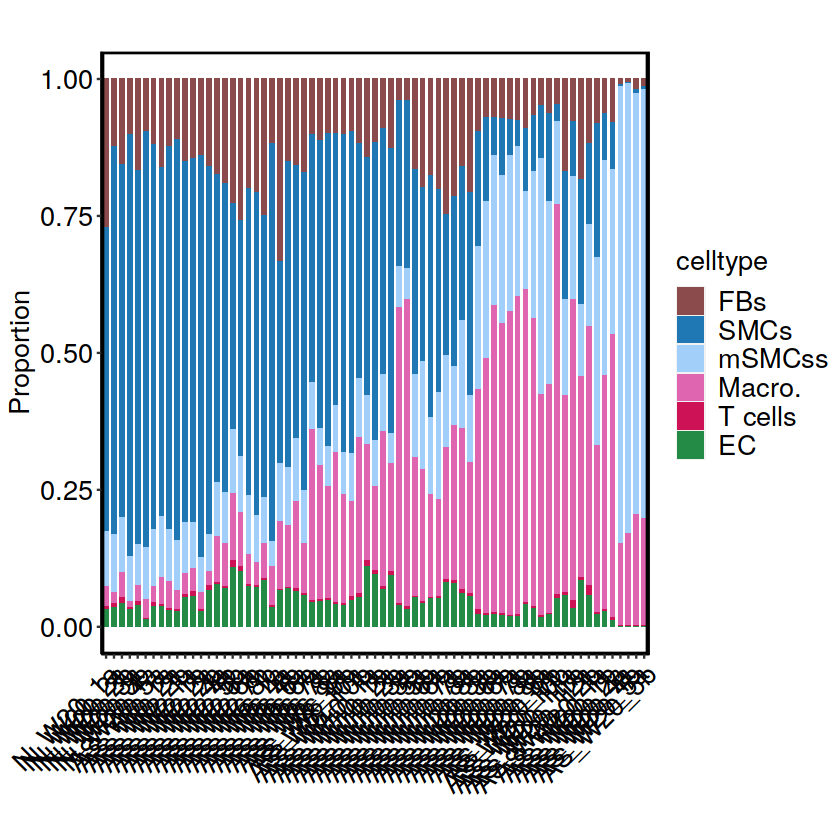

In [66]:
m <- as.matrix(table(as.character(mer$Celltype), mer$`Week ID`))
plot_df <- melt(m)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$y <- factor(plot_df$y, levels = ord)
plot_df$celltype <- factor(plot_df$celltype, levels = c('FBs','SMCs','mSMCss','Macro.','T cells','EC'))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',width = 0.6,position="fill")+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title    = element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'), # .
    axis.line.x = element_line (color = 'black',linetype = 'solid'), #.
    panel.background=element_rect(fill="white"),
    panel.border = element_rect(linetype = 'solid', size = 1.2,fill = NA) # .
  )+scale_fill_manual(values = cols1)
print(p1)
ggsave("s1_celltype_ST_STAT.pdf",p1,width = 20,height = 6)